<a href="https://colab.research.google.com/github/Jenoprabakar/DeepLearning-lab-experiments/blob/main/dl8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import requests

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

data = requests.get(url).text

print(data[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [ ]:
data = data.lower()

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

total_words = len(tokenizer.word_index) + 1
print("Total words:", total_words)

Total words: 12633


In [ ]:
input_sequences = []

for line in data.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

In [ ]:
max_seq_len = max([len(seq) for seq in input_sequences])

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')
)

In [ ]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

In [ ]:
model = Sequential()

model.add(Embedding(total_words, 100, input_length=max_seq_len-1))

model.add(LSTM(150, return_sequences=True))

model.add(LSTM(100))

model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=30,
    batch_size=128
)

In [ ]:
def predict_next_word(text, model, tokenizer, max_seq_len):

    token_list = tokenizer.texts_to_sequences([text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_seq_len-1,
        padding='pre'
    )

    predicted = np.argmax(model.predict(token_list), axis=-1)

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            return word

In [ ]:
seed_text = "to be or not"

next_word = predict_next_word(seed_text, model, tokenizer, max_seq_len)

print("Input:", seed_text)
print("Predicted next word:", next_word)

In [ ]:
"""
Experiment 8: Next Word Prediction using Recurrent Neural Network (RNN)
Complete implementation covering all 11 steps.
"""

# ─────────────────────────────────────────────
# STEP 1: Collect Textual Dataset
# ─────────────────────────────────────────────

corpus = """
Natural language processing is a fascinating field of artificial intelligence.
Recurrent neural networks are powerful models for sequential data.
The human brain processes language naturally and efficiently.
Deep learning models learn patterns from large amounts of text data.
Language models predict the next word based on previous context.
Machine learning algorithms improve through training on data.
Neural networks consist of layers of interconnected neurons.
Text processing involves tokenization and numerical representation.
Sequential models maintain memory of previous inputs through hidden states.
Artificial intelligence is transforming the way we interact with technology.
Natural language understanding requires knowledge of grammar and semantics.
Training deep learning models requires significant computational resources.
Word embeddings capture semantic relationships between words.
The attention mechanism improves the performance of language models.
Backpropagation through time is used to train recurrent neural networks.
"""

print("=" * 60)
print("STEP 1: Dataset Collected")
print(f"Total characters: {len(corpus)}")
print(f"Total sentences : {len([s for s in corpus.strip().split('.') if s.strip()])}")


# ─────────────────────────────────────────────
# STEP 2: Preprocessing
# ─────────────────────────────────────────────

import re
import string

def preprocess(text):
    # Case normalization
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenization
    tokens = text.split()
    return tokens

tokens = preprocess(corpus)

print("\n" + "=" * 60)
print("STEP 2: Preprocessing Complete")
print(f"Total tokens : {len(tokens)}")
print(f"Sample tokens: {tokens[:10]}")


# ─────────────────────────────────────────────
# STEP 3: Numerical Representation
# ─────────────────────────────────────────────

vocab       = sorted(set(tokens))
vocab_size  = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

print("\n" + "=" * 60)
print("STEP 3: Vocabulary Built")
print(f"Vocabulary size : {vocab_size}")
print(f"Sample mappings : {dict(list(word_to_idx.items())[:5])}")


# ─────────────────────────────────────────────
# STEP 4: Generate Input-Output Sequence Pairs
# ─────────────────────────────────────────────

import numpy as np

SEQ_LENGTH = 5   # number of context words used as input

def create_sequences(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        input_seq  = [word_to_idx[w] for w in tokens[i:i + seq_len]]
        target     = word_to_idx[tokens[i + seq_len]]
        X.append(input_seq)
        y.append(target)
    return np.array(X), np.array(y)

X, y = create_sequences(tokens, SEQ_LENGTH)

# One-hot encode targets
def one_hot(indices, size):
    ohe = np.zeros((len(indices), size))
    ohe[np.arange(len(indices)), indices] = 1
    return ohe

Y = one_hot(y, vocab_size)

print("\n" + "=" * 60)
print("STEP 4: Sequence Pairs Generated")
print(f"Input  shape : {X.shape}  (samples × seq_len)")
print(f"Output shape : {Y.shape}  (samples × vocab_size)")
print(f"Example input : {[idx_to_word[i] for i in X[0]]}")
print(f"Example target: {idx_to_word[y[0]]}")


# ─────────────────────────────────────────────
# STEP 5: Initialize Hidden States
# ─────────────────────────────────────────────

HIDDEN_SIZE  = 128
EMBED_SIZE   = 64
LEARNING_RATE = 0.01

def init_hidden(batch_size=1):
    return np.zeros((batch_size, HIDDEN_SIZE))

print("\n" + "=" * 60)
print("STEP 5: Hidden State Initialization")
print(f"Hidden state shape : (batch_size, {HIDDEN_SIZE})")
print(f"Initial values     : all zeros")


# ─────────────────────────────────────────────
# STEP 6: Construct RNN Architecture
# ─────────────────────────────────────────────

class SimpleRNN:
    """
    Minimal RNN with:
      Embedding  → EMBED_SIZE
      RNN cell   → HIDDEN_SIZE
      Output     → vocab_size (softmax)
    """

    def __init__(self, vocab_size, embed_size, hidden_size):
        self.vocab_size  = vocab_size
        self.embed_size  = embed_size
        self.hidden_size = hidden_size

        # Xavier / He initialisation
        scale_e  = np.sqrt(2.0 / (vocab_size  + embed_size))
        scale_wx = np.sqrt(2.0 / (embed_size  + hidden_size))
        scale_wh = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_wy = np.sqrt(2.0 / (hidden_size + vocab_size))

        self.E   = np.random.randn(vocab_size,  embed_size)  * scale_e   # embedding
        self.Wx  = np.random.randn(embed_size,  hidden_size) * scale_wx  # input → hidden
        self.Wh  = np.random.randn(hidden_size, hidden_size) * scale_wh  # hidden → hidden
        self.bh  = np.zeros(hidden_size)
        self.Wy  = np.random.randn(hidden_size, vocab_size)  * scale_wy  # hidden → output
        self.by  = np.zeros(vocab_size)

    # ── activation helpers ──────────────────
    @staticmethod
    def tanh(x):        return np.tanh(x)

    @staticmethod
    def tanh_deriv(x):  return 1.0 - np.tanh(x) ** 2

    @staticmethod
    def softmax(x):
        e = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # ── forward pass ────────────────────────
    def forward(self, x_seq):
        """
        x_seq : (seq_len,) word indices
        Returns output probabilities (vocab_size,) and cache for BPTT.
        """
        seq_len = len(x_seq)
        embeds, hiddens, outputs = [], [], []
        h = np.zeros(self.hidden_size)

        for t in range(seq_len):
            emb = self.E[x_seq[t]]                       # embedding lookup
            h   = self.tanh(emb @ self.Wx + h @ self.Wh + self.bh)
            y_t = self.softmax(h @ self.Wy + self.by)
            embeds.append(emb)
            hiddens.append(h.copy())
            outputs.append(y_t)

        cache = (x_seq, embeds, hiddens, outputs)
        return outputs[-1], cache                        # predict after last token

    # ── cross-entropy loss ───────────────────
    @staticmethod
    def cross_entropy(pred, target):
        return -np.sum(target * np.log(pred + 1e-9))

    # ── backward pass (BPTT) ────────────────
    def backward(self, cache, target):
        x_seq, embeds, hiddens, outputs = cache
        seq_len = len(x_seq)

        # gradient of loss w.r.t. softmax output
        dL_dy = outputs[-1] - target

        # output layer gradients
        h_last   = hiddens[-1]
        dWy      = np.outer(h_last, dL_dy)
        dby      = dL_dy.copy()
        dh_next  = dL_dy @ self.Wy.T

        # BPTT accumulators
        dE  = np.zeros_like(self.E)
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)

        for t in reversed(range(seq_len)):
            h_prev = hiddens[t - 1] if t > 0 else np.zeros(self.hidden_size)
            dh     = dh_next * self.tanh_deriv(hiddens[t])
            dWx   += np.outer(embeds[t], dh)
            dWh   += np.outer(h_prev,    dh)
            dbh   += dh
            dE[x_seq[t]] += dh @ self.Wx.T
            dh_next = dh @ self.Wh.T

        # gradient clipping (±5)
        for g in [dE, dWx, dWh, dbh, dWy, dby]:
            np.clip(g, -5, 5, out=g)

        grads = dict(E=dE, Wx=dWx, Wh=dWh, bh=dbh, Wy=dWy, by=dby)
        return grads

    # ── parameter update (SGD) ──────────────
    def update(self, grads, lr):
        self.E  -= lr * grads['E']
        self.Wx -= lr * grads['Wx']
        self.Wh -= lr * grads['Wh']
        self.bh -= lr * grads['bh']
        self.Wy -= lr * grads['Wy']
        self.by -= lr * grads['by']

    # ── parameter count ─────────────────────
    def param_count(self):
        return (self.E.size + self.Wx.size + self.Wh.size +
                self.bh.size + self.Wy.size + self.by.size)


model = SimpleRNN(vocab_size, EMBED_SIZE, HIDDEN_SIZE)

print("\n" + "=" * 60)
print("STEP 6: RNN Architecture Constructed")
print(f"  Embedding   : ({vocab_size}, {EMBED_SIZE})")
print(f"  Wx (input)  : ({EMBED_SIZE}, {HIDDEN_SIZE})")
print(f"  Wh (recur.) : ({HIDDEN_SIZE}, {HIDDEN_SIZE})")
print(f"  Wy (output) : ({HIDDEN_SIZE}, {vocab_size})")
print(f"  Total params: {model.param_count():,}")


# ─────────────────────────────────────────────
# STEP 7: Unfold Computational Graph
# ─────────────────────────────────────────────

def visualize_unfolded_graph(seq_len=SEQ_LENGTH):
    print("\n" + "=" * 60)
    print("STEP 7: Unfolded Computational Graph (text)")
    print()
    print("  Input sequence  : x₀ → x₁ → x₂ → x₃ → x₄")
    print()
    for t in range(seq_len):
        label = "← predict" if t == seq_len - 1 else ""
        print(f"  t={t}  xₜ → [Embed] → [RNN cell: h_{t} = tanh(Wx·eₜ + Wh·h_{t-1} + b)] → ŷ_{t} {label}")
        if t < seq_len - 1:
            print(f"         {'':40s}↓ h_{t} passed to t={t+1}")
    print()
    print("  Shared weights Wx, Wh, Wy are reused at every time-step.")

visualize_unfolded_graph()


# ─────────────────────────────────────────────
# STEP 8: Train with BPTT
# ─────────────────────────────────────────────

EPOCHS       = 50
PRINT_EVERY  = 10

def train(model, X, Y, epochs, lr, print_every):
    loss_history = []
    n_samples = len(X)

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        indices = np.random.permutation(n_samples)

        for i in indices:
            x_seq  = X[i]
            target = Y[i]

            pred, cache = model.forward(x_seq)
            loss        = model.cross_entropy(pred, target)
            grads       = model.backward(cache, target)
            model.update(grads, lr)
            epoch_loss += loss

        avg_loss = epoch_loss / n_samples
        loss_history.append(avg_loss)

        if epoch % print_every == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  |  Loss: {avg_loss:.4f}")

    return loss_history

print("\n" + "=" * 60)
print("STEP 8: Training with Backpropagation Through Time (BPTT)")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Samples/epoch : {len(X)}")
print()

loss_history = train(model, X, Y, EPOCHS, LEARNING_RATE, PRINT_EVERY)
print(f"\n  Initial loss : {loss_history[0]:.4f}")
print(f"  Final loss   : {loss_history[-1]:.4f}")


# ─────────────────────────────────────────────
# STEP 9: Validate Prediction Performance
# ─────────────────────────────────────────────

def evaluate(model, X, y, top_k=3):
    correct_top1 = 0
    correct_topk = 0
    n = len(X)

    for i in range(n):
        pred, _ = model.forward(X[i])
        top_preds = np.argsort(pred)[-top_k:][::-1]
        if top_preds[0] == y[i]:
            correct_top1 += 1
        if y[i] in top_preds:
            correct_topk += 1

    return correct_top1 / n, correct_topk / n

acc1, acc3 = evaluate(model, X, y, top_k=3)

print("\n" + "=" * 60)
print("STEP 9: Validation Performance")
print(f"  Top-1 accuracy : {acc1 * 100:.2f}%")
print(f"  Top-3 accuracy : {acc3 * 100:.2f}%")
print(f"  (Trained on {len(X)} samples with vocab size {vocab_size})")


# ─────────────────────────────────────────────
# STEP 10: Predict Next Word for Unseen Sentences
# ─────────────────────────────────────────────

def predict_next_word(model, sentence, word_to_idx, idx_to_word,
                      seq_len=SEQ_LENGTH, top_n=5):
    words = preprocess(sentence)
    # keep last seq_len words; pad with unknown if too short
    words = words[-seq_len:] if len(words) >= seq_len else words
    known = [w for w in words if w in word_to_idx]

    if len(known) < seq_len:
        return f"  [Need at least {seq_len} known words; got {len(known)}]"

    x_seq        = [word_to_idx[w] for w in known[-seq_len:]]
    probs, _     = model.forward(np.array(x_seq))
    top_indices  = np.argsort(probs)[-top_n:][::-1]

    results = [(idx_to_word[i], probs[i] * 100) for i in top_indices]
    return results

test_sentences = [
    "recurrent neural networks are powerful models for",
    "natural language processing is a fascinating field of",
    "deep learning models learn patterns from large amounts of",
    "training deep learning models requires significant computational",
    "the attention mechanism improves the performance of language",
]

print("\n" + "=" * 60)
print("STEP 10: Next Word Predictions")

for sentence in test_sentences:
    predictions = predict_next_word(model, sentence, word_to_idx, idx_to_word)
    print(f"\n  Input : \"{sentence}\"")
    if isinstance(predictions, str):
        print(predictions)
    else:
        print("  Top-5 predictions:")
        for rank, (word, prob) in enumerate(predictions, 1):
            bar = "█" * int(prob / 5)
            print(f"    {rank}. {word:<22} {prob:5.1f}%  {bar}")


# ─────────────────────────────────────────────
# STEP 11: Analyze Contextual Learning Capability
# ─────────────────────────────────────────────

def analyze_context(model, word_to_idx, idx_to_word, target_word,
                    seq_len=SEQ_LENGTH, n_samples=200):
    """
    Sample random sequences from the corpus;
    report how often 'target_word' appears in the top-3 predictions.
    """
    hits   = 0
    trials = 0
    indices = list(range(len(X)))
    np.random.shuffle(indices)

    for i in indices[:n_samples]:
        actual = idx_to_word[y[i]]
        if actual == target_word:
            pred, _ = model.forward(X[i])
            top3    = [idx_to_word[j] for j in np.argsort(pred)[-3:][::-1]]
            if target_word in top3:
                hits += 1
            trials += 1

    return hits, trials

print("\n" + "=" * 60)
print("STEP 11: Contextual Learning Analysis")

# Perplexity on training set
total_log_prob = 0.0
for i in range(len(X)):
    pred, _ = model.forward(X[i])
    total_log_prob += np.log(pred[y[i]] + 1e-9)

perplexity = np.exp(-total_log_prob / len(X))
print(f"\n  Perplexity on training corpus : {perplexity:.2f}")
print(f"  (Lower is better; random baseline ≈ {vocab_size:.0f})")

# Contextual recall for selected words
analyze_targets = ["learning", "networks", "models", "language", "data"]
print(f"\n  Top-3 recall per target word (out of {200} samples):")
for target in analyze_targets:
    hits, trials = analyze_context(model, word_to_idx, idx_to_word,
                                   target, seq_len=SEQ_LENGTH)
    rate = (hits / trials * 100) if trials > 0 else 0
    print(f"    {target:<12} : {hits}/{trials} contexts correct  ({rate:.1f}%)")

# Loss curve summary
print("\n  Loss curve summary (every 10 epochs):")
for i, loss in enumerate(loss_history):
    if (i + 1) % 10 == 0:
        bar = "█" * int((loss_history[0] - loss) / loss_history[0] * 30)
        print(f"    Epoch {i+1:3d}  loss={loss:.4f}  improvement {bar}")

print("\n" + "=" * 60)
print("Experiment 8 Complete — RNN Next Word Predictor trained successfully.")
print("=" * 60)

STEP 1: Dataset Collected
Total characters: 1043
Total sentences : 15

STEP 2: Preprocessing Complete
Total tokens : 134
Sample tokens: ['natural', 'language', 'processing', 'is', 'a', 'fascinating', 'field', 'of', 'artificial', 'intelligence']

STEP 3: Vocabulary Built
Vocabulary size : 88
Sample mappings : {'a': 0, 'algorithms': 1, 'amounts': 2, 'and': 3, 'are': 4}

STEP 4: Sequence Pairs Generated
Input  shape : (129, 5)  (samples × seq_len)
Output shape : (129, 88)  (samples × vocab_size)
Example input : ['natural', 'language', 'processing', 'is', 'a']
Example target: fascinating

STEP 5: Hidden State Initialization
Hidden state shape : (batch_size, 128)
Initial values     : all zeros

STEP 6: RNN Architecture Constructed
  Embedding   : (88, 64)
  Wx (input)  : (64, 128)
  Wh (recur.) : (128, 128)
  Wy (output) : (128, 88)
  Total params: 41,688

STEP 7: Unfolded Computational Graph (text)

  Input sequence  : x₀ → x₁ → x₂ → x₃ → x₄

  t=0  xₜ → [Embed] → [RNN cell: h_0 = tanh(Wx·

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical
import string

# ------------------------------------------------------------
# 1. Collect textual dataset
# ------------------------------------------------------------

text_data = """
Artificial intelligence is transforming the world.
Machine learning enables computers to learn from data.
Deep learning is a subset of machine learning.
Natural language processing helps computers understand language.
Neural networks are powerful models for pattern recognition.
Recurrent neural networks are useful for sequence prediction.
Predicting the next word improves typing experience.
Language models learn relationships between words.
"""

# ------------------------------------------------------------
# 2. Preprocessing
# Case normalization, punctuation removal
# ------------------------------------------------------------

text_data = text_data.lower()

text_data = text_data.translate(str.maketrans('', '', string.punctuation))

# ------------------------------------------------------------
# 3. Tokenization (Convert words into numerical form)
# ------------------------------------------------------------

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_data])

word_index = tokenizer.word_index
total_words = len(word_index) + 1

print("Total words:", total_words)

# ------------------------------------------------------------
# 4. Generate input-output sequence pairs
# ------------------------------------------------------------

input_sequences = []

for line in text_data.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Find maximum sequence length
max_sequence_len = max([len(x) for x in input_sequences])

# Padding sequences
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

# Split into predictors and labels
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# One-hot encode output
y = to_categorical(y, num_classes=total_words)

# ------------------------------------------------------------
# 5. Initialize hidden states & construct RNN architecture
# ------------------------------------------------------------

model = Sequential()

# Word embedding
model.add(Embedding(total_words, 64, input_length=max_sequence_len-1))

# RNN layer
model.add(SimpleRNN(128, return_sequences=False))

# Output layer
model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# 6. Train model using Backpropagation Through Time (BPTT)
# ------------------------------------------------------------

history = model.fit(
    X,
    y,
    epochs=50,
    verbose=1
)

# ------------------------------------------------------------
# 7. Validate prediction performance
# ------------------------------------------------------------

loss, accuracy = model.evaluate(X, y, verbose=0)

print("Training Accuracy:", accuracy)

# ------------------------------------------------------------
# 8. Predict next word for unseen sentence
# ------------------------------------------------------------

def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )

    predicted = model.predict(token_list, verbose=0)

    predicted_word_index = np.argmax(predicted)

    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word


# ------------------------------------------------------------
# 9. Test predictions
# ------------------------------------------------------------

seed_sentences = [
    "machine learning",
    "artificial intelligence",
    "recurrent neural",
    "natural language"
]

for sentence in seed_sentences:
    next_word = predict_next_word(sentence)
    print(f"Input: {sentence} -> Predicted Next Word: {next_word}")


Total words: 45


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 918ms/step - accuracy: 0.0400 - loss: 3.8017
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1000 - loss: 3.7324
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1800 - loss: 3.6683
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2000 - loss: 3.6024
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2000 - loss: 3.5302
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 - loss: 3.4520
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2200 - loss: 3.3924
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2000 - loss: 3.3248
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2600 - loss: 3.2561
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2200 - loss: 3.1783 
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4200 - loss: 3.0831
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4600 - loss: 2.9807

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs = model.predict(X)

# Convert probabilities to predicted class
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y back to labels
y_true = np.argmax(y, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step


In [ ]:
print("Classification Report:\n")

print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          17       1.00      1.00      1.00         1
          18       1.00      1.00      1.00         1
   

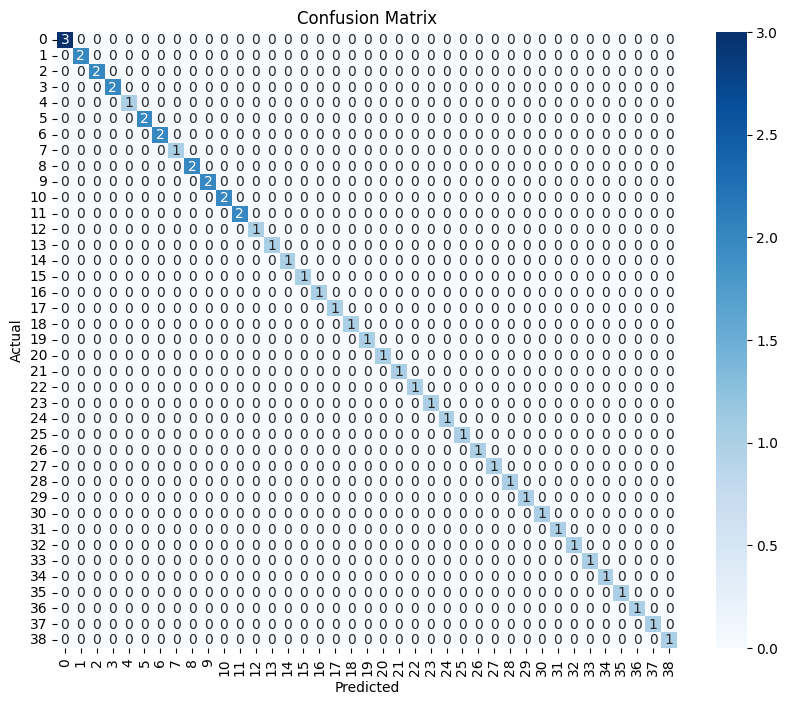

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

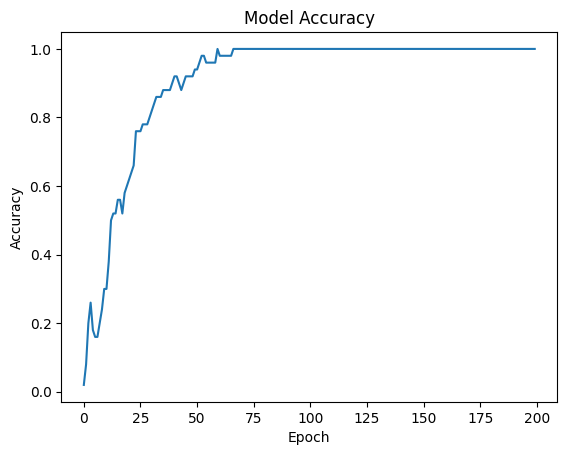

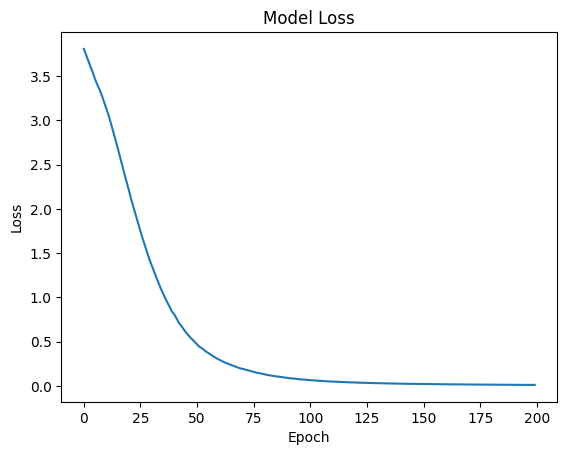

In [ ]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
# Function to predict next word
def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )

    predicted = model.predict(token_list, verbose=0)

    predicted_word_index = np.argmax(predicted)

    predicted_word = ""

    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break

    return predicted_word


# ----------------------------------------------------
# User input prediction loop
# ----------------------------------------------------

print("\nNext Word Prediction System")
print("Type a sentence to predict the next word.")
print("Type 'exit' to stop.\n")

while True:

    sentence = input("Enter a sentence: ")

    if sentence.lower() == "exit":
        break

    next_word = predict_next_word(sentence)

    print("Predicted Next Word:", next_word)
    print()


Next Word Prediction System
Type a sentence to predict the next word.
Type 'exit' to stop.

Enter a sentence: the cat
Predicted Next Word: neural

Enter a sentence: can you predict
Predicted Next Word: neural

Enter a sentence: exit
